<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ вакансий из HeadHunter
   

In [1]:
import pandas as pd
import psycopg2

# Юнит 3. Предварительный анализ данных

1. Напишите запрос, который посчитает количество вакансий в нашей базе (вакансии находятся в таблице vacancies). 

In [ ]:
# импортируем данные для соединения с базой данных из файла "config.txt"
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_3_1 = f'''SELECT
    COUNT(*) AS cnt
FROM public.vacancies
            '''
df = pd.read_sql_query(query_3_1, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\3176416428.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_3_1, connection)


,cnt
0,49197


##### результат запроса  
→ В базе содержится 49 197 вакансий.

2. Напишите запрос, который посчитает количество работодателей (таблица employers). 

In [8]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_3_2 = f'''SELECT
    COUNT(*) AS cnt
FROM public.employers
            '''
df = pd.read_sql_query(query_3_2, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\3791120138.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_3_2, connection)


,cnt
0,23501


##### результат запроса
→ Всего в нашей базе содержится 23 501 работодатель.

3. Посчитате с помощью запроса количество регионов (таблица areas).

In [9]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_3_3 = f'''SELECT
    COUNT(*) AS cnt
FROM public.areas
            '''
df = pd.read_sql_query(query_3_3, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\2301360020.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_3_3, connection)


,cnt
0,1362


##### результат запроса
→ В базе данных указано 1362 региона.

4. Посчитате с помощью запроса количество сфер деятельности в базе (таблица industries).

In [10]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_3_4 = f'''SELECT
    COUNT(*) AS cnt
FROM public.industries
            '''
df = pd.read_sql_query(query_3_4, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\135925277.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_3_4, connection)


,cnt
0,294


##### результат запроса
→ Всего указано 294 сферы деятельности.

***

#### * выводы по предварительному анализу данных
→ Судя по тому, что вакансий более чем в два раза больше, чем работодателей, можно утверждать, что одни и те же работодатели подавали более одной заявки от своего имени.    
География представлена широко — 1 362 региона, что позволяет анализировать рынок труда территориально.     
Сфер деятельности достаточно большое количество - 294, это стоит считать уникальным признаком, и рассмотреть его детальнее.

# Юнит 4. Детальный анализ вакансий

1. Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).
Отсортируйте по количеству вакансий в порядке убывания.

In [14]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_4_1 = f'''SELECT
    a.name AS city_name,
    COUNT(v.id) AS cnt
FROM public.areas a
JOIN public.vacancies v on a.id = v.area_id
GROUP BY a.id
ORDER BY 2 desc
            '''
df = pd.read_sql_query(query_4_1, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\1132987466.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_4_1, connection)


,city_name,cnt
0,Москва,5333
1,Санкт-Петербург,2851
2,Минск,2112
3,Новосибирск,2006
4,Алматы,1892
...,...,...
764,Кизляр,1
765,Джизак,1
766,Эртиль,1
767,Арсеньев,1


C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\841721613.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_4_1, connection)


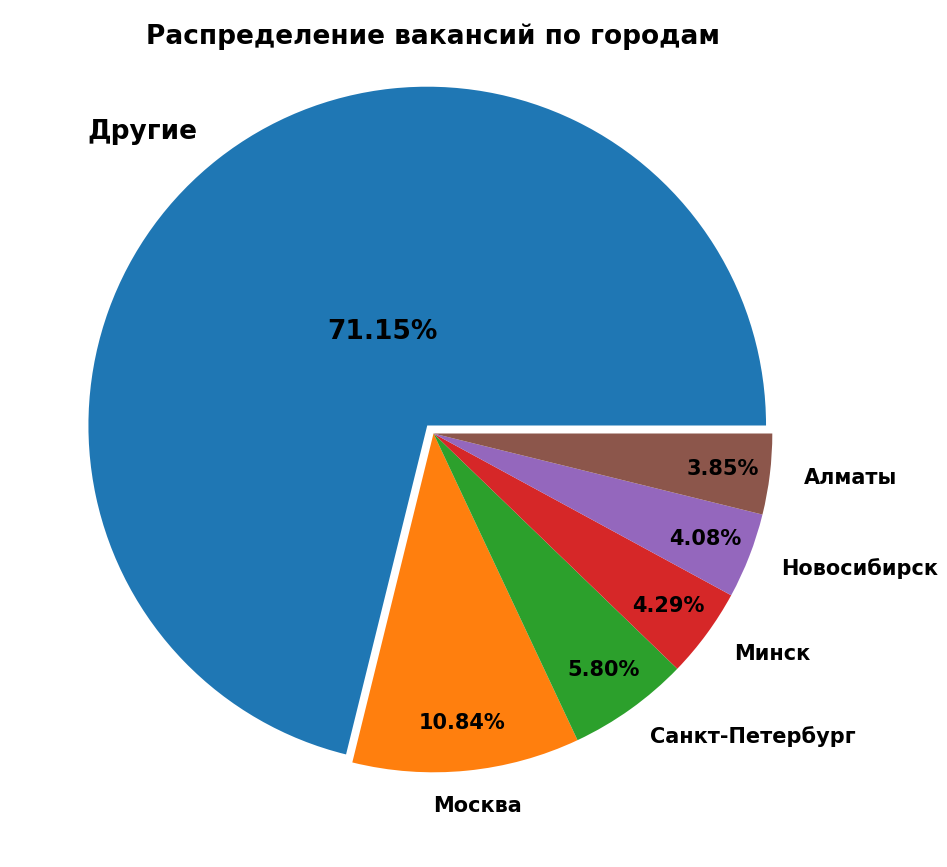

In [15]:
import matplotlib.pyplot as plt
df = pd.read_sql_query(query_4_1, connection)

top_n = 5
popular_cities = df['city_name'].head(top_n).values # возьмём например 5 самых популярных по вакансиям городов, остальные именуем "Другими"
df['city_grouped'] = df['city_name'].apply(lambda x: x if x in popular_cities else 'Другие')
grouped = df.groupby('city_grouped')['cnt'].sum() # группируем по новым уникальным значениям городов
grouped = grouped.sort_values(ascending=False) # сортируем для последовательного отображения на графике

# строим круговую диаграмму распределения вакансий по городам
plt.figure(figsize=(11, 11))
wedges, texts, autotexts = plt.pie(
    grouped,
    labels=grouped.index,
    autopct='%.2f%%',
    explode = [0.03] + [0]*(len(grouped)-1),
    labeldistance=1.1,
    pctdistance=0.86,
    textprops={'weight':'bold', 'fontsize':15}
)
# редактируем отдельные подписи
autotexts[0].set_fontsize(19)
autotexts[0].set_position((-0.15, 0.3))
texts[0].set_fontsize(19)
texts[1].set_position((0, -1.1))

plt.title('Распределение вакансий по городам', 
          fontsize=19,
          weight='bold',
          y=0.95
)
plt.show()

##### результат запроса  
→ Большинство работодателей размещают вакансии в крупных городах с концентрированной рабочей силой, как Москва, Санкт-Петербург, Минск и тому подобных. Москва заметно опережает остальные города по числу размещённых вакансий.

2. Напишите запрос, чтобы определить у какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой.

In [16]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_4_2 = f'''SELECT
    COUNT(*) AS salary_count
FROM public.vacancies
WHERE 
    salary_from is not null
    OR salary_to is not null
            '''
df = pd.read_sql_query(query_4_2, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\565020496.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_4_2, connection)


,salary_count
0,24073


##### результат запроса  
→ Больше половины вакансий имеет пустые значения в полях с заработной платой. Следует провести подробный анализ и обработку данных для построения предсказательной модели заработной платы, ибо данный пункт является ключевым для поиска потенциальных сотрудников.

3. Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого.

In [17]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_4_3 = f'''SELECT
    ROUND(AVG(salary_from)) as avg_min,
    ROUND(AVG(salary_to)) as avg_max
FROM public.vacancies
            '''
df = pd.read_sql_query(query_4_3, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\4159911907.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_4_3, connection)


,avg_min,avg_max
0,71065.0,110537.0


##### результат запроса
→ Запрос выдаёт диапазон средних значений заработной платы. Это позволяет ориентироваться на этот уровень как на типичное предложение для большинства позиций, где указана зарплата.

4. Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Результат отсортируйте по убыванию количества.


In [19]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_4_4 = f'''SELECT
    schedule,
    employment,
    COUNT(*) AS cnt
FROM public.vacancies
GROUP BY
    schedule,
    employment
ORDER BY 3 DESC
            '''
df = pd.read_sql_query(query_4_4, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\1816409007.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_4_4, connection)


,schedule,employment,cnt
0,Полный день,Полная занятость,35367
1,Удаленная работа,Полная занятость,7802
2,Гибкий график,Полная занятость,1593
3,Удаленная работа,Частичная занятость,1312
4,Сменный график,Полная занятость,940
5,Полный день,Стажировка,569
6,Вахтовый метод,Полная занятость,367
7,Полный день,Частичная занятость,347
8,Гибкий график,Частичная занятость,312
9,Полный день,Проектная работа,141


##### результат запроса
→ Сильно превалирует над другими сочетание: "Полный день" + "Полная занятость". Действительно, это самый популярный режим работы, который требуют работодатели.

5. Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта. 

In [20]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_4_5 = f'''SELECT
    experience,
    COUNT(*)
FROM public.vacancies
GROUP BY
    experience
ORDER BY 2
            '''
df = pd.read_sql_query(query_4_5, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\3290318214.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_4_5, connection)


,experience,count
0,Более 6 лет,1337
1,Нет опыта,7197
2,От 3 до 6 лет,14511
3,От 1 года до 3 лет,26152


##### результат запроса  
→ По результатам запроса видим, что наибольшое число вакансий содержит опыт работы от 1 года до 3 лет.

***

### * выводы по детальному анализу вакансий

→ В результате написания запроса и проделанного анализа извлеченной информации мы определили основные значимые характеристики:
1. самые популярные города по количеству вакансий;
2. диапазон средней заработной платы;
3. самые распространенный тип и режим занятости;
4. распределение количества вакансий по опыту работы.

# Юнит 5. Анализ работодателей

1. Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.

In [23]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_5_1 = f"""
WITH employers AS (
    SELECT 
        e.name AS employers,
        COUNT(*) AS cnt 
    FROM public.employers as e
    JOIN public.vacancies as v on e.id = v.employer_id
    GROUP BY e.id
)

(SELECT *
FROM employers
ORDER BY 2 DESC
LIMIT 1) /*выводим первую строку*/

UNION ALL /*присоединяем пятую строку*/

(SELECT *
FROM employers
ORDER BY 2 DESC
OFFSET 4
LIMIT 1)
            """
df = pd.read_sql_query(query_5_1, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\434646490.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_1, connection)


,employers,cnt
0,Яндекс,1933
1,Газпром нефть,331


C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\616256208.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_1_0, connection)
C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\616256208.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('grouped_emp')['cnt'].sum().sort_values(ascending=False)


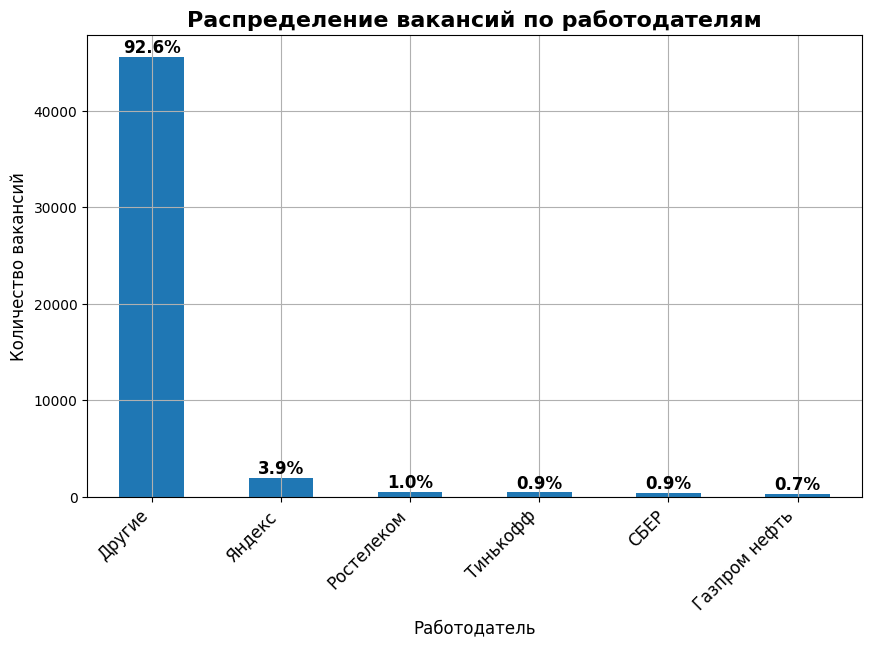

In [62]:
import matplotlib.pyplot as plt
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_5_1_0 = f"""SELECT 
    e.name AS employers,
    COUNT(*) AS cnt 
FROM public.employers as e
JOIN public.vacancies as v on e.id = v.employer_id
GROUP BY e.id
ORDER BY 2 DESC
              """

df = pd.read_sql_query(query_5_1_0, connection)

top_n = 5
most_popular = df['employers'].head(top_n).values # возьмём например 5 самых первых работодателей по количеству вакансий
df['grouped_emp'] = df['employers'].apply(lambda x: x if x in most_popular else 'Другие') # создаём новый столбец с меньшим числом уникальных работодателей

df['grouped_emp'] = df['grouped_emp'].astype('category') # приводим новый столбец к типу 'category'

# --- Группировка ---
grouped = df.groupby('grouped_emp')['cnt'].sum().sort_values(ascending=False)
percent = grouped / grouped.sum()

plt.figure(figsize=(10, 6))
ax = grouped.plot(kind='bar', grid=True)

# подписи над столбцами
for i, value in enumerate(grouped):
    ax.text(
        i, value + grouped.max()*0.01, # делаем подпись чуть выше столбца
        f"{percent.iloc[i]*100:.1f}%",
        ha='center',
        fontsize=12,
        weight='bold'
)

plt.title('Распределение вакансий по работодателям', fontsize=16, weight='bold')
plt.xlabel('Работодатель', fontsize=12)
plt.ylabel('Количество вакансий', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)

plt.show()

##### результат запроса  
→ Распределение вакансий по работодателям показывает выраженное лидерство компании «Яндекс», на которую приходится 3,9% всех объявлений. Остальные крупные работодатели — Ростелеком, Тинькофф, Сбер и Газпром — формируют менее 1% каждая. При этом подавляющая часть вакансий приходится на категорию «Другие», что указывает на высокую фрагментированность рынка и большое количество компаний, размещающих небольшое число объявлений.

2. Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.
Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей.


In [63]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_5_2 = f'''SELECT
    a.name,
    COUNT(e.id) AS employers_count,
    COUNT(v.id) AS vacancies_cnt
FROM public.areas a
LEFT JOIN public.employers e ON e.area = a.id
LEFT JOIN public.vacancies v ON v.area_id = a.id
GROUP BY
    a.id
HAVING
    COUNT(v.id) = 0 
ORDER BY 2 DESC
            '''
df = pd.read_sql_query(query_5_2, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\1853704688.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_2, connection)


,name,employers_count,vacancies_cnt
0,Россия,410,0
1,Казахстан,207,0
2,Московская область,75,0
3,Краснодарский край,19,0
4,Беларусь,18,0
...,...,...,...
588,Лиман (Астраханская область),0,0
589,Хоринск,0,0
590,Старица,0,0
591,Ессентукская,0,0


##### результат запроса  
→ Запрос выявил регионы, в которых наибольшее число работодателей при полном отсутствии вакансий. Лидирующая позиция у записи «Россия», что указывает на некорректное или слишком обобщённое заполнение регионального поля — страна не может выступать в роли конкретного региона размещения вакансий. Аналогичная ситуация наблюдается для «Казахстана», "Беларуси". Это свидетельствует о необходимости уточнения географической информации и использования более детализированных региональных значений (город, область) для повышения качества данных и корректности аналитики.

In [60]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_5_2_0 = f'''
SELECT
    a.name,
    COALESCE(e.employers_count, 0) AS employers_count,
    COALESCE(v.vacancies_count, 0) AS vacancies_count
FROM areas a
LEFT JOIN (
    SELECT area, COUNT(*) AS employers_count
    FROM employers
    GROUP BY area
) e ON e.area = a.id
LEFT JOIN (
    SELECT area_id, COUNT(*) AS vacancies_count
    FROM vacancies
    GROUP BY area_id
) v ON v.area_id = a.id
ORDER BY employers_count DESC
            '''
df = pd.read_sql_query(query_5_2_0, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\864128953.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_2_0, connection)


,name,employers_count,vacancies_count
0,Москва,5864,5333
1,Санкт-Петербург,2217,2851
2,Минск,1115,2112
3,Алматы,721,1892
4,Екатеринбург,609,1698
...,...,...,...
1357,Североморск,0,3
1358,Толмачево,0,0
1359,Костомукша,0,4
1360,Иваново (Брестская область),0,0


##### результат запроса
→ Выводим для каждого региона количество работодателей и вакансий в нём. 

3. Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии. Отсортируйте результат по убыванию количества.


In [135]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_5_3 = f'''SELECT
    e.name AS employers,
    COUNT(distinct v.area_id) as "cnt_areas"
FROM public.employers e
LEFT JOIN public.vacancies v ON e.id = v.employer_id
LEFT JOIN public.areas a ON a.id = v.area_id
GROUP BY e.id
ORDER BY 2 DESC
            '''
df = pd.read_sql_query(query_5_3, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_4032\293382292.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_3, connection)


,employers,cnt_areas
0,Яндекс,181
1,Ростелеком,152
2,Спецремонт,116
3,Поляков Денис Иванович,88
4,ООО ЕФИН,71
...,...,...
23496,Но Смокинг,0
23497,МАСТЕРСКАЯ CREED,0
23498,Dzing Finance,0
23499,КОРС,0


##### результат запроса  
→ По результатам запроса компания Яндекс также занимает лидирующую позицию по регионам, можно сделать предварительный вывод, что, вероятно, компания размещает одни и те же вакансии сразу в нескольких регионах.

4. Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности. 

In [34]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_5_4 = f'''SELECT
    COUNT(*)
FROM employers as e
LEFT JOIN employers_industries ei ON ei.employer_id = e.id
WHERE 
    ei.industry_id is null
            '''
df = pd.read_sql_query(query_5_4, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\3198296920.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_4, connection)


,count
0,8419


##### результат запроса  
→ У значительной части работодателей — 8 419 компаний — не указана сфера деятельности.

5. Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности. 

In [36]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_5_5 = f'''SELECT
    e.name
FROM
    employers as e
LEFT JOIN
    employers_industries ei ON ei.employer_id = e.id
GROUP BY
    e.id
HAVING
    COUNT(ei.industry_id) = 4
ORDER BY 1
OFFSET 2
LIMIT 1
            '''
df = pd.read_sql_query(query_5_5, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\369445490.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_5, connection)


,name
0,2ГИС


##### результат запроса  
→ На третьем месте находится компания 2ГИС.

6. С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана Разработка программного обеспечения.


In [37]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_5_6 = f'''SELECT
    COUNT(*) AS employers_count
FROM
    employers_industries ei
JOIN
    industries i ON i.id = ei.industry_id
WHERE
    i.name = 'Разработка программного обеспечения'
            '''
df = pd.read_sql_query(query_5_6, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\3306204406.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_6, connection)


,employers_count
0,3553


##### результат запроса  
→ Сфера "разработки программного обеспечения" является достаточно популярной, указана у 3553 работодателей.

7. Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании. Результат отсортируйте по возрастанию количества.

Список городов-милионников надо взять [отсюда](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8). 

Если возникнут трудности с этим задание посмотрите материалы модуля  PYTHON-17. Как получать данные из веб-источников и API. 

In [50]:
# код для получения списка городов-милионников
import requests
from bs4 import BeautifulSoup
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.36'
}
url = 'https://ru.wikipedia.org/wiki/Города-миллионеры_России'
response = requests.get(url, headers=headers)
page = BeautifulSoup(response.text, 'html.parser')
cities = []
rows = page.table.tbody.find_all("td")
for row in rows:
    a_tag = row.find("a")
    if a_tag:
        cities.append(a_tag.text) # поочерёдно добавляем названия городов в общий список cities
cities_string = "('" + "','".join(cities) + "')" # делаем строку из названий городов для передачи оператору "IN" в запросе SQL

In [52]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_5_7 = """WITH yandex_million AS (
    SELECT 
        a.name AS name,
        v.id AS vacancy_id
    FROM
        vacancies v
    JOIN
        employers e ON v.employer_id = e.id
    JOIN
        areas a ON v.area_id = a.id
    WHERE
        a.name IN """+cities_string+"""
        AND e.name = 'Яндекс'
)

SELECT
    name,
    COUNT(vacancy_id) AS vacancy_cnt
FROM
    yandex_million
GROUP BY name

UNION ALL

SELECT 'Total', COUNT(vacancy_id)
FROM
    yandex_million
ORDER BY vacancy_cnt
            """
df = pd.read_sql_query(query_5_7, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\3259428739.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_7, connection)


,name,vacancy_cnt
0,Омск,21
1,Челябинск,22
2,Красноярск,23
3,Волгоград,24
4,Пермь,25
5,Ростов-на-Дону,25
6,Казань,25
7,Уфа,26
8,Самара,26
9,Краснодар,30


##### результат запроса  
→ 485 вакансий от компании "Яндекс" размещены в городах-миллионниках.

***

### * выводы по анализу работодателей  
→ Проведённый анализ работодателей позволил получить целостное представление о структуре рынка труда. Распределение вакансий по сферам деятельности показало доминирование IT‑отрасли, которая лидирует как по числу вакансий, так и по количеству компаний. Анализ работодателей выявил высокую фрагментированность рынка: значительная часть вакансий приходится на несколько крупных компаний, тогда как множество работодателей публикуют единичные объявления. Исследование регионального разреза показало неравномерность распределения как работодателей, так и вакансий, а также выявило случаи некорректного указания региона. Отдельный анализ по Яндексу в городах‑миллионниках подтвердил концентрацию вакансий в крупнейших урбанистических центрах. В совокупности эти результаты дают структурированное понимание того, как распределены работодатели, вакансии и отрасли на рынке труда.

# Юнит 6. Предметный анализ

1. Сколько вакансий имеет отношение к данным?

Считаем, что вакансия имеет отношение к данным, если в её названии содержатся слова 'data' или 'данн'.

*Подсказка: Обратите внимание, что названия вакансий могут быть написаны в любом регистре.* 


In [158]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_6_1 = f'''SELECT
    COUNT(*) as cnt
FROM vacancies as v
WHERE
    (lower(v.name) like '%data%') or (lower(v.name) like '%данн%')
            '''
df = pd.read_sql_query(query_6_1, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_4032\4204307335.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_1, connection)


,cnt
0,1771


##### результат запроса  
→ Запрос показал, что в базе как минимум 1771 вакансия, связанная с данными. 

2. Сколько есть подходящих вакансий для начинающего дата-сайентиста? 
Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:
* 'data scientist'
* 'data science'
* 'исследователь данных'
* 'ML' (здесь не нужно брать вакансии по HTML)
* 'machine learning'
* 'машинн%обучен%'

** В следующих заданиях мы продолжим работать с вакансиями по этому условию.*

Считаем вакансиями для специалистов уровня Junior следующие:
* в названии есть слово 'junior' *или*
* требуемый опыт — Нет опыта *или*
* тип трудоустройства — Стажировка.
 

In [160]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_6_2 = f'''SELECT
    COUNT(*)
FROM public.vacancies
WHERE 
    (name ILIKE '%junior%'
    OR employment ILIKE '%стажировка%'
    OR experience ILIKE '%нет опыта%')
  AND 
    (
      (name ILIKE '%ML%' AND name NOT ILIKE '%html%')
      OR name ILIKE '%data scientist%'
      OR name ILIKE '%data science%'
      OR name ILIKE '%исследователь данных%'
      OR name ILIKE '%machine learning%'
      OR name ILIKE '%машинн%обучен%'
    )
            '''
df = pd.read_sql_query(query_6_2, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_4032\3568220934.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_2, connection)


,count
0,51


##### результат запроса  
→ Для неопытных дата-сайентистов в базе данных насчитывается по приблизительному анализу 51 вакансия.

3. Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

** Критерии для отнесения вакансии к DS указаны в предыдущем задании.*

In [166]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_6_3 = f'''SELECT
    COUNT(*)
FROM public.vacancies
WHERE 
    (key_skills ILIKE '%SQL%'
    OR key_skills ILIKE '%postgres%')
AND 
    (
      (name ILIKE '%ML%' AND name NOT ILIKE '%html%')
      OR name ILIKE '%data scientist%'
      OR name ILIKE '%data science%'
      OR name ILIKE '%исследователь данных%'
      OR name ILIKE '%machine learning%'
      OR name ILIKE '%машинн%обучен%'
    )
            '''
df = pd.read_sql_query(query_6_3, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_4032\307270550.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_3, connection)


,count
0,229


##### результат запроса  
→ Для специалистов DS с указанными ключевыми навыками работы в SQL или postgres содержится 229 вакансий.

4. Проверьте, насколько популярен Python в требованиях работодателей к DS.Для этого вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

** Это можно сделать помощью запроса, аналогичного предыдущему.*

In [165]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_6_4 = f'''
SELECT COUNT(*)
FROM public.vacancies
WHERE 
    (key_skills ILIKE '%python%')
AND 
    (
      (name ILIKE '%ML%' AND name NOT ILIKE '%html%')
      OR name ILIKE '%data scientist%'
      OR name ILIKE '%data science%'
      OR name ILIKE '%исследователь данных%'
      OR name ILIKE '%machine learning%'
      OR name ILIKE '%машинн%обучен%'
    )
            '''
df = pd.read_sql_query(query_6_4, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_4032\2108101857.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_4, connection)


,count
0,357


##### результат запроса  
→ Ключевой навык "Python" для требования к DS указан в 357 вакансиях.

5. Сколько ключевых навыков в среднем указывают в вакансиях для DS?
Ответ округлите до двух знаков после точки-разделителя.

In [164]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_6_5 = f'''SELECT
ROUND(AVG(LENGTH(key_skills) - LENGTH(REPLACE(key_skills, CHR(9), '')) + 1 ), 2) AS avg_skills
FROM public.vacancies
WHERE
    (key_skills IS NOT NULL AND key_skills != '')
AND 
    (
      (name LIKE '%ML%' AND name NOT ILIKE '%html%')
      OR name ILIKE '%data scientist%'
      OR name ILIKE '%data science%'
      OR name ILIKE '%исследователь данных%'
      OR name ILIKE '%machine learning%'
      OR name ILIKE '%машинн%обучен%'
    )
            '''
df = pd.read_sql_query(query_6_5, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_4032\294844374.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_5, connection)


,avg_skills
0,6.41


##### результат запроса  
→ В среднем в вакансиях для DS указывают 6 ключевых навыков.

6. Напишите запрос, позволяющий вычислить, какую зарплату для DS в **среднем** указывают для каждого типа требуемого опыта (уникальное значение из поля *experience*). 

При решении задачи примите во внимание следующее:
1. Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
2. Если заполнены оба поля с зарплатой, то считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, то его и считаем зарплатой по вакансии.
3. Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null). Чтобы избежать этой ситуацию, мы воспользуемся функцией [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull), которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос `select 1 + coalesce(null, 0)`

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа. 

In [ ]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_6_6 = f'''SELECT
experience,
ROUND(AVG(coalesce((salary_from + salary_to) / 2, salary_from, salary_to))) as avg_salary
FROM vacancies
WHERE
    (
      (name LIKE '%ML%' AND name NOT ILIKE '%html%')
      OR name ILIKE '%data scientist%'
      OR name ILIKE '%data science%'
      OR name ILIKE '%исследователь данных%'
      OR name ILIKE '%machine learning%'
      OR name ILIKE '%машинн%обучен%'
    )
GROUP BY experience
ORDER BY 1
            '''
df = pd.read_sql_query(query_6_6, connection)
display(df)
connection.close()

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_13020\2898694039.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_6, connection)


,experience,avg_salary
0,Более 6 лет,NaN
1,Нет опыта,74643.0
2,От 1 года до 3 лет,139675.0
3,От 3 до 6 лет,243115.0


##### результат запроса  
→ Дата-сайентист с опытом работы от 3 до 6 лет претендует на заработную плату, в среднем составляющую 243 115 рублей. 

***

### * выводы по предметному анализу

→ Анализ вакансий показал, что рынок специалистов по данным остаётся достаточно активным: в базе содержится 1771 релевантная вакансия. При этом предложения для кандидатов без опыта встречаются значительно реже — всего около 51 позиции, что подчёркивает высокие требования отрасли к уровню подготовки.  
→ Ключевые навыки играют важную роль в формировании требований: SQL или Postgres упоминаются в 229 вакансиях, а Python — в 357, что подтверждает их статус базовых инструментов для специалистов по данным. В среднем работодатели указывают около шести навыков в одной вакансии, что отражает многопрофильность и комплексность задач в сфере DS.  
→ Анализ заработных плат демонстрирует ожидаемую зависимость от опыта: специалисты с опытом от 3 до 6 лет могут рассчитывать на средний уровень дохода около 240 тысяч рублей, тогда как начинающие кандидаты получают в среднем около 74 тысяч рублей.

# Общий вывод по проекту

→ Проведённый предметный анализ вакансий, связанных с Data Science, позволил сформировать достаточно объёмное представление о текущем состоянии рынка и его ключевых тенденциях. Уже на первом этапе стало ясно, что спрос на специалистов по данным остаётся высоким: в базе содержится как минимум 1771 вакансия, относящаяся к этой сфере. Однако распределение предложений по уровням опыта показывает, что рынок ориентирован прежде всего на специалистов с практическими навыками — для кандидатов без опыта нашлось лишь около 51 вакансии. Это подчёркивает, что вход в профессию требует определённой подготовки и подтверждённых компетенций.

→ Анализ требований к навыкам выявил, что работодатели ожидают от дата‑сайентистов достаточно широкого набора компетенций: в среднем в одной вакансии указывается около шести ключевых навыков. При этом востребованными остаются Python (упоминается в 357 вакансиях) и SQL/Postgres (229 вакансий), что подтверждает их статус базовых инструментов в работе с данными. Эти результаты позволяют говорить о том, что рынок предъявляет комплексные требования и ценит специалистов, способных работать с данными на всех этапах — от извлечения и обработки до анализа и построения моделей.

→ Исследование уровня заработных плат также демонстрирует закономерную зависимость от опыта. Специалисты с опытом от трёх до шести лет могут рассчитывать на средний доход около 243 тысяч рублей, тогда как начинающие получают примерно 74 тысячи.

→ На основе полученных данных можно наметить несколько направлений для дальнейшего исследования и прогнозирования. Во‑первых, логично изучить динамику востребованности навыков: если Python и SQL уже доминируют, то можно попытаться определить, какие технологии будут усиливать свои позиции в ближайшие годы. Во‑вторых, анализ зарплат можно расширить, построив модели зависимости дохода от набора навыков, региона или сферы деятельности работодателя.

→ Кроме того, перспективным направлением выглядит исследование региональной структуры спроса: сравнение регионов по количеству вакансий, уровню зарплат и активности работодателей может выявить точки роста и регионы с дефицитом специалистов. Наконец, можно углубиться в анализ поведения крупных работодателей: изучить, какие компании формируют основные требования к навыкам, как они распределяют вакансии по регионам и какие карьерные траектории предлагают.

→ Таким образом, проведённый анализ задаёт основу для дальнейших исследований, которые помогут глубже понять динамику спроса, структуру навыков и перспективы развития профессии.

#### <center> Дополнительные исследования данных

1. Посчитаем количество вакансий в каждой сфере деятельности.

In [2]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
query_5_6_0 = f'''
SELECT 
    i.name AS industry,
    COUNT(*) AS vacancies_count
FROM
    vacancies v
JOIN
    employers e ON v.employer_id = e.id
JOIN
    employers_industries ei ON e.id = ei.employer_id
JOIN
    industries i ON i.id = ei.industry_id
GROUP BY
    i.name
ORDER BY
    vacancies_count DESC
            '''
df = pd.read_sql_query(query_5_6_0, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_12856\245915127.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_6_0, connection)


,industry,vacancies_count
0,Разработка программного обеспечения,12499
1,"Системная интеграция, автоматизации технологи...",11034
2,"Интернет-компания (поисковики, платежные систе...",6413
3,Банк,2742
4,Мобильная связь,1585
...,...,...
288,Спортивная федерация,5
289,Химчистка,4
290,"Ассоциация в сфере культуры, искусства",2
291,Автошкола,1


2. Посчитаем количество работодателей в каждой из сфер деятельности.

In [3]:
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
query_5_6_1 = f'''
SELECT 
    i.name AS industry,
    COUNT(DISTINCT ei.employer_id) AS employers_count
FROM
    employers_industries ei
JOIN
    industries i ON i.id = ei.industry_id
GROUP BY 1
ORDER BY 2 DESC
            '''
df = pd.read_sql_query(query_5_6_1, connection)
df

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_12856\3859117950.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_6_1, connection)


,industry,employers_count
0,Разработка программного обеспечения,3553
1,"Системная интеграция, автоматизации технологи...",2993
2,"Интернет-компания (поисковики, платежные систе...",1675
3,"Маркетинговые, рекламные, BTL, дизайнерские, E...",798
4,Консалтинговые услуги,662
...,...,...
289,Благотворительная организация,4
290,"Лифтовое хозяйство (монтаж, сервис, ремонт)",4
291,"Ботанический сад, зоопарк, заповедник",3
292,Автошкола,3


#### результаты запросов    

→ IT‑сектор доминирует как по числу вакансий, так и по числу работодателей (Разработка ПО; Системная интеграция и автоматизация; Интернет‑компании). Такое совпадение лидеров в двух таблицах — сильный индикатор устойчивости отрасли.  
Разработка ПО — абсолютный лидер - 12 499 вакансий, 3 553 работодателя  
Это означает:
1. отрасль не только крупная, но и очень фрагментированная — много компаний, каждая создаёт относительно небольшое число вакансий;
2. спрос на разработчиков стабильно высокий;
3. рынок труда в этой сфере конкурентный со стороны работодателей.  

→ Системная интеграция и автоматизация — второй мощный кластер.  
Интернет‑компании занимают устойчивое третье место.  

→ Банковская сфера создаёт много вакансий, но представлена ограниченным числом крупных компаний.  
Маркетинг и консалтинг имеют много компаний, но низкий спрос на специалистов.  

3. Построим распределение DS‑вакансий по городам.

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_12856\3085486244.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_2_0, connection)


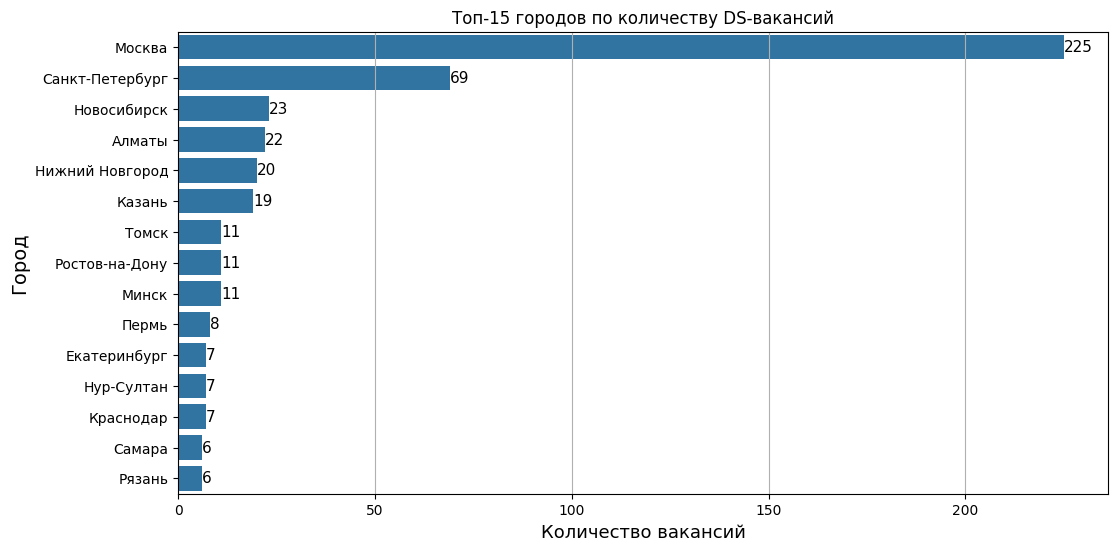

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_6_2_0 = f'''SELECT
    a.name AS city,
    COUNT(*) AS vacancies_count
FROM vacancies as v
LEFT JOIN areas a ON v.area_id = a.id
WHERE 
      (v.name ILIKE '%ML%' AND v.name NOT ILIKE '%html%')
      OR v.name ILIKE '%data scientist%'
      OR v.name ILIKE '%data science%'
      OR v.name ILIKE '%исследователь данных%'
      OR v.name ILIKE '%machine learning%'
      OR v.name ILIKE '%машинн%обучен%'
GROUP BY 1
ORDER BY 2 DESC
            '''
df = pd.read_sql_query(query_6_2_0, connection)

plt.figure(figsize=(12,6))
ax = sns.barplot(data=df.head(15), x="vacancies_count", y="city") # выбираем топ-15 городов
plt.title("Топ‑15 городов по количеству DS‑вакансий")
plt.xlabel("Количество вакансий", fontsize=13)
plt.ylabel("Город", fontsize=14)
plt.grid(axis="x")

# добавляем подписи к каждому столбцу
for p in ax.patches:
    value = int(p.get_width())
    ax.text(
        p.get_width(),
        p.get_y() + p.get_height() / 2, # вертикальное центрирование
        value,
        va="center", # выравнивание подписи
        fontsize=11
    )

plt.show()

4. Построим распределение DS‑вакансий по работодателям.

C:\Users\Home-PC\AppData\Local\Temp\ipykernel_12856\4006645313.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_2_1, connection)


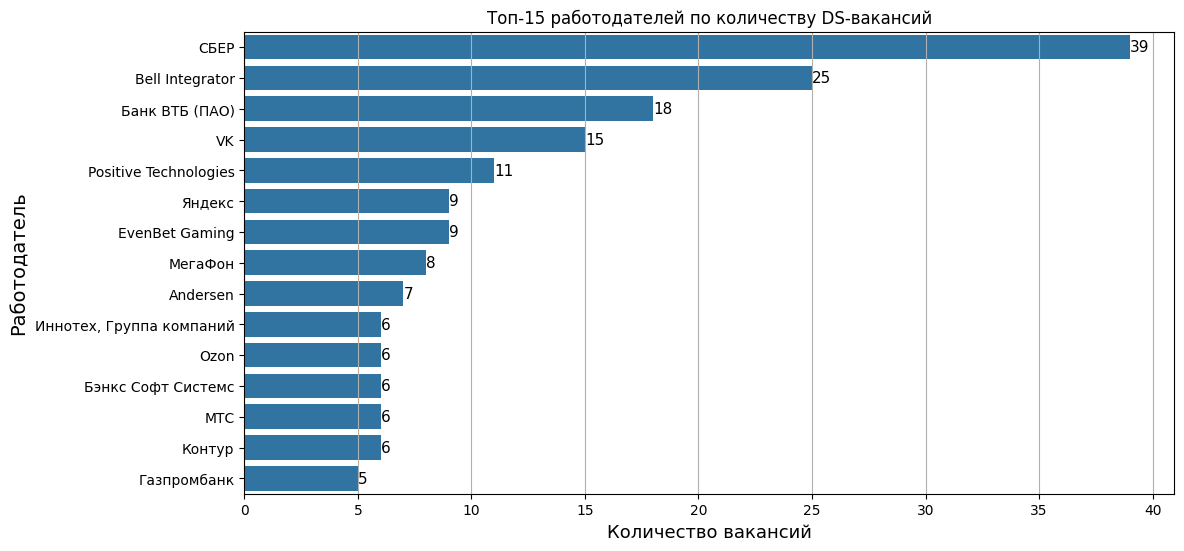

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
params = {k:v.strip() for k, v in (l.split('=') for l in open('config.txt'))}
connection = psycopg2.connect(**params)
# текст запроса
query_6_2_1 = f'''SELECT
    e.name AS employer,
    COUNT(*) AS vacancies_count
FROM vacancies as v
LEFT JOIN employers e ON v.employer_id = e.id
WHERE 
      (v.name ILIKE '%ML%' AND v.name NOT ILIKE '%html%')
      OR v.name ILIKE '%data scientist%'
      OR v.name ILIKE '%data science%'
      OR v.name ILIKE '%исследователь данных%'
      OR v.name ILIKE '%machine learning%'
      OR v.name ILIKE '%машинн%обучен%'
GROUP BY 1
ORDER BY 2 DESC
            '''
df = pd.read_sql_query(query_6_2_1, connection)

plt.figure(figsize=(12,6))
ax = sns.barplot(data=df.head(15), x="vacancies_count", y="employer") # выбираем топ-15 работодателей
plt.title("Топ‑15 работодателей по количеству DS‑вакансий")
plt.xlabel("Количество вакансий", fontsize=13)
plt.ylabel("Работодатель", fontsize=14)
plt.grid(axis="x")

# добавляем подписи
for p in ax.patches:
    value = int(p.get_width())
    ax.text(
        p.get_width(), 
        p.get_y() + p.get_height() / 2,
        value,
        va="center",
        fontsize=11
    )

plt.show()

##### Выводы по графикам
1. Рынок крайне сконцентрирован в Москве. Москва — 225 вакансий, что в 3 раза больше, чем в Санкт‑Петербурге. Это подтверждает, что Москва остаётся главным центром найма DS‑специалистов. Остальные города с небольшим количеством вакансий.
2. Спрос на Data Scientist формируют в первую очередь крупные банки, IT‑компании и технологические корпорации. Абсолютный лидер — Сбер: 39 вакансий — почти вдвое больше, чем у следующего работодателя.